<a href="https://colab.research.google.com/github/chithrakumardakshan-cloud/northstar-analytics/blob/main/notebooks/02_r_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================================
# NORTHSTAR URBAN MOBILITY ANALYTICS
# R ANALYTICS
# ==========================================

# STEP 1 — INSTALL PACKAGES

install.packages("dplyr")
install.packages("ggplot2")
install.packages("stringr")
install.packages("scales")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [2]:
# STEP 2 — LOAD LIBRARIES

library(dplyr)
library(ggplot2)
library(stringr)
library(scales)

cat("Libraries loaded successfully.")


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




Libraries loaded successfully.

In [3]:
# STEP 3 — LOAD DATASETS

orders <- read.csv("orders.csv")
deliveries <- read.csv("deliveries.csv")
customers <- read.csv("customers.csv")
drivers <- read.csv("drivers.csv")
vehicles <- read.csv("vehicles.csv")
hubs <- read.csv("hubs.csv")
incidents <- read.csv("incidents.csv")
complaints <- read.csv("complaints.csv")
app_events <- read.csv("app_events.csv")

cat("Datasets loaded successfully.")

Datasets loaded successfully.

In [4]:
# STEP 4 — CHECK DATASET STRUCTURE

str(orders)
str(deliveries)

# STEP 5 — PREVIEW DATA

head(orders)
head(deliveries)

'data.frame':	1250 obs. of  11 variables:
 $ order_id             : chr  "O00001" "O00002" "O00003" "O00004" ...
 $ customer_id          : chr  "C0292" "C0459" "C0161" "C0520" ...
 $ service_type         : chr  "Passenger" "Passenger" "Passenger" "Parcel" ...
 $ order_created_at     : chr  "2024-08-20 14:43:00" "2024-05-14 22:16:00" "2025-09-02 14:37:00" "2025-01-11 17:15:00" ...
 $ promised_window_hours: int  6 24 4 2 12 1 2 4 12 6 ...
 $ pickup_zone          : chr  "Airport" "North" "West" "RiverSide" ...
 $ dropoff_zone         : chr  "South" "AIRPORT" "AIRPORT" "North" ...
 $ priority_level       : chr  "Medium" "Low" "High" "Medium" ...
 $ order_value          : num  126.7 109.3 33.5 10 125.6 ...
 $ booking_channel      : chr  "App" "App" "Phone" "App" ...
 $ special_handling_flag: int  0 0 0 1 0 1 0 0 0 0 ...
'data.frame':	950 obs. of  13 variables:
 $ delivery_id                  : chr  "DL00001" "DL00002" "DL00003" "DL00004" ...
 $ order_id                     : chr  "O00938" "

,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,<int>
1,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0
2,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0
3,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0
4,O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,1
5,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,0
6,O00006,C0437,Retail,2024-08-05 04:55:00,1,CENTRAL,East,High,151.44,Web,1


,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>,<dbl>
1,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05
2,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41
3,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51
4,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62
5,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,0,4.18,9.22
6,DL00006,O00029,D037,V098,H03,2024-09-11 12:40:00,2024-09-12 17:11:52.384869,Delayed,13.84,0,0,1.57,9.58


In [5]:
# STEP 6 — DATA CLEANING

clean_zone <- function(x) {
  str_to_title(trimws(x))
}

orders$pickup_zone <- clean_zone(orders$pickup_zone)
orders$dropoff_zone <- clean_zone(orders$dropoff_zone)

customers$home_zone <- clean_zone(customers$home_zone)

drivers$base_zone <- clean_zone(drivers$base_zone)

vehicles$assigned_zone <- clean_zone(vehicles$assigned_zone)

app_events$zone_context <- clean_zone(app_events$zone_context)

cat("Zone cleaning completed.")

Zone cleaning completed.

In [6]:
# STEP 7 — CHECK MISSING VALUES

sapply(list(
  orders = orders,
  deliveries = deliveries,
  complaints = complaints
), function(df) sum(is.na(df)))

orders deliveries complaints 
         0         14         16

In [7]:
# ANALYSIS 1 — DELIVERY STATUS BY HUB

delivery_hub <- deliveries %>%
  left_join(hubs, by = "hub_id")

delivery_summary <- delivery_hub %>%
  group_by(hub_name, delivery_status) %>%
  summarise(total = n(), .groups = "drop")

delivery_summary

hub_name,delivery_status,total
<chr>,<chr>,<int>
Airport Hub,Delayed,27
Airport Hub,Failed,15
Airport Hub,OnTime,62
Central Core,Delayed,25
Central Core,Failed,23
Central Core,OnTime,67
East Dock,Delayed,23
East Dock,Failed,11
East Dock,OnTime,85


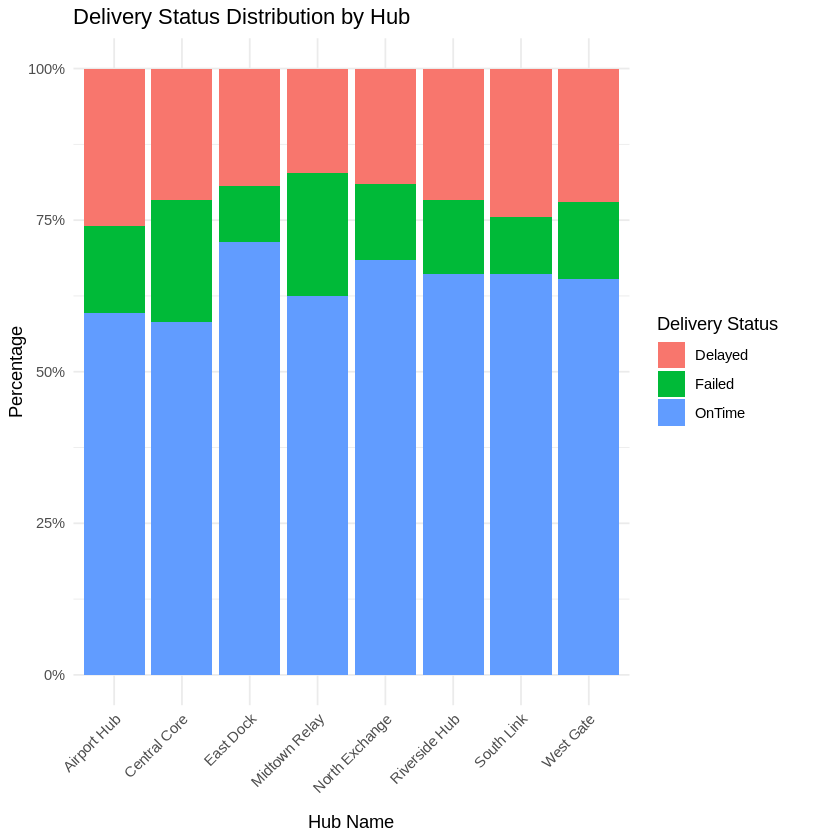

In [8]:
# CHART 1 — DELIVERY STATUS BY HUB

ggplot(delivery_summary,
       aes(x = hub_name,
           y = total,
           fill = delivery_status)) +

  geom_bar(stat = "identity",
           position = "fill") +

  scale_y_continuous(labels = percent_format()) +

  labs(
    title = "Delivery Status Distribution by Hub",
    x = "Hub Name",
    y = "Percentage",
    fill = "Delivery Status"
  ) +

  theme_minimal() +

  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

In [9]:
# ANALYSIS 2 — DRIVER OVERRIDES

driver_data <- deliveries %>%
  left_join(drivers, by = "driver_id")

override_summary <- driver_data %>%
  group_by(base_zone) %>%
  summarise(
    avg_override = mean(manual_route_override_count, na.rm = TRUE),
    avg_rating = mean(customer_rating_post_delivery, na.rm = TRUE)
  )

override_summary

base_zone,avg_override,avg_rating
<chr>,<dbl>,<dbl>
Airport,0.9375000,3.892661
Central,0.9398496,3.796818
Ctr,1.0666667,4.002414
East,0.8737864,3.897573
North,1.0430622,3.816316
Riverside,0.9285714,3.890947
South,1.0264901,3.934595
West,0.9210526,3.826757


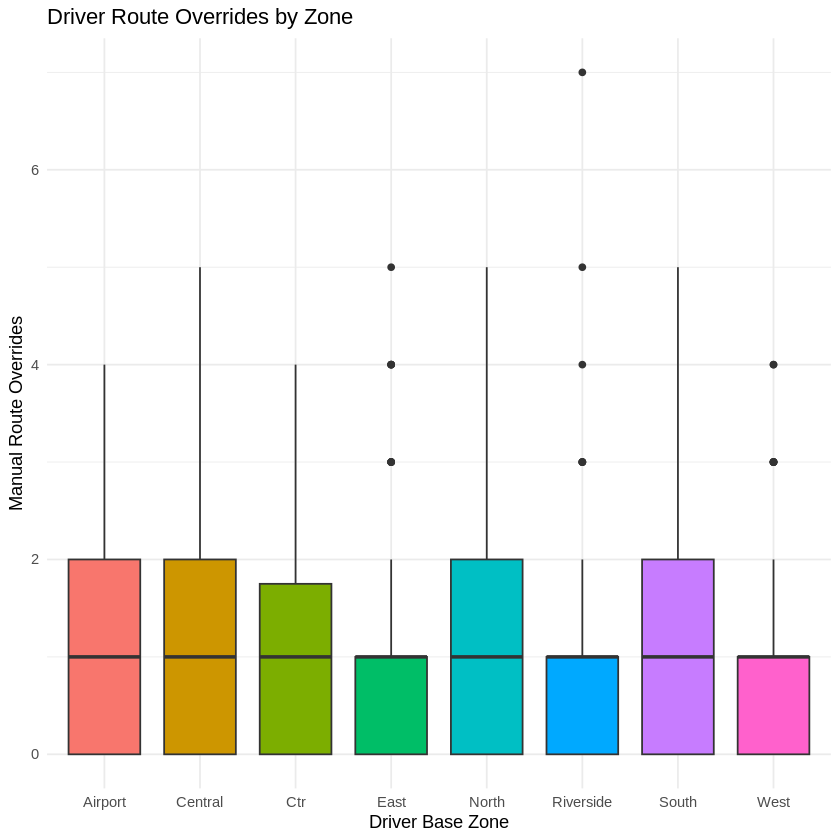

In [10]:
# CHART 2 — DRIVER OVERRIDES BY ZONE

ggplot(driver_data,
       aes(x = base_zone,
           y = manual_route_override_count,
           fill = base_zone)) +

  geom_boxplot() +

  labs(
    title = "Driver Route Overrides by Zone",
    x = "Driver Base Zone",
    y = "Manual Route Overrides"
  ) +

  theme_minimal() +

  theme(
    legend.position = "none"
  )

In [11]:
# ANALYSIS 3 — COMPLAINT TREND

complaints$created_at <- as.Date(complaints$created_at)

complaints$month <- format(
  complaints$created_at,
  "%Y-%m"
)

complaint_trend <- complaints %>%
  group_by(month, severity) %>%
  summarise(total = n(), .groups = "drop")

complaint_trend

month,severity,total
<chr>,<chr>,<int>
2024-01,High,5
2024-01,Low,3
2024-01,Medium,8
2024-02,High,2
2024-02,Low,3
2024-02,Medium,4
2024-03,High,9
2024-03,Low,5
2024-03,Medium,6


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


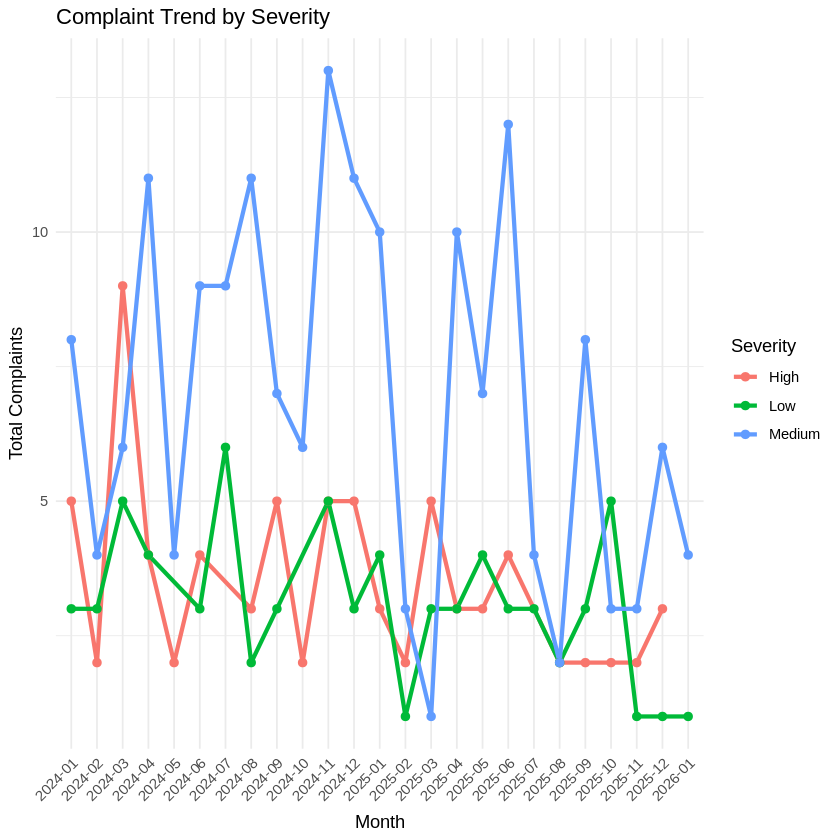

In [12]:
# CHART 3 — COMPLAINT TREND OVER TIME

ggplot(complaint_trend,
       aes(x = month,
           y = total,
           color = severity,
           group = severity)) +

  geom_line(size = 1.2) +

  geom_point(size = 2) +

  labs(
    title = "Complaint Trend by Severity",
    x = "Month",
    y = "Total Complaints",
    color = "Severity"
  ) +

  theme_minimal() +

  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

In [13]:
# ANALYSIS 4 — BATTERY HEALTH VS CUSTOMER RATING

vehicle_delivery <- deliveries %>%
  left_join(vehicles, by = "vehicle_id")

battery_analysis <- vehicle_delivery %>%
  filter(
    !is.na(battery_health_pct),
    !is.na(customer_rating_post_delivery)
  )

head(battery_analysis)

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost,vehicle_type,assigned_zone,commission_date,battery_health_pct,odometer_km,maintenance_status,telematics_version
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<chr>
1,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05,EV,Central,2024-06-09 16:18:00,78.4,29849,Active,v2.2
2,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41,Diesel,Airport,2025-09-17 08:52:00,68.6,78468,Active,v2.2
3,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51,Diesel,East,2025-12-09 16:47:00,55.9,15278,Active,v2.2
4,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62,Hybrid,East,2025-06-05 13:40:00,83.3,85635,Active,v2.1
5,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,0,4.18,9.22,EV,Riverside,2025-05-24 09:58:00,94.2,210683,InRepair,v2.0
6,DL00006,O00029,D037,V098,H03,2024-09-11 12:40:00,2024-09-12 17:11:52.384869,Delayed,13.84,0,0,1.57,9.58,Diesel,West,2025-12-29 15:01:00,69.7,73011,Active,v2.1


`geom_smooth()` using formula = 'y ~ x'


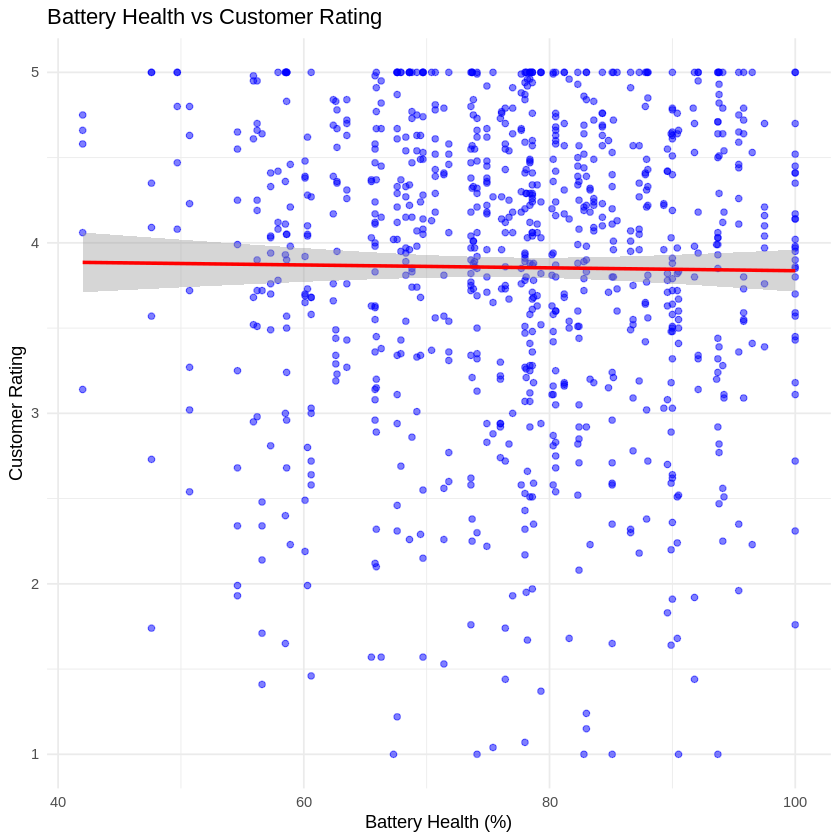

In [14]:
# CHART 4 — BATTERY HEALTH VS RATING

ggplot(battery_analysis,
       aes(x = battery_health_pct,
           y = customer_rating_post_delivery)) +

  geom_point(alpha = 0.5,
             color = "blue") +

  geom_smooth(method = "lm",
              color = "red") +

  labs(
    title = "Battery Health vs Customer Rating",
    x = "Battery Health (%)",
    y = "Customer Rating"
  ) +

  theme_minimal()

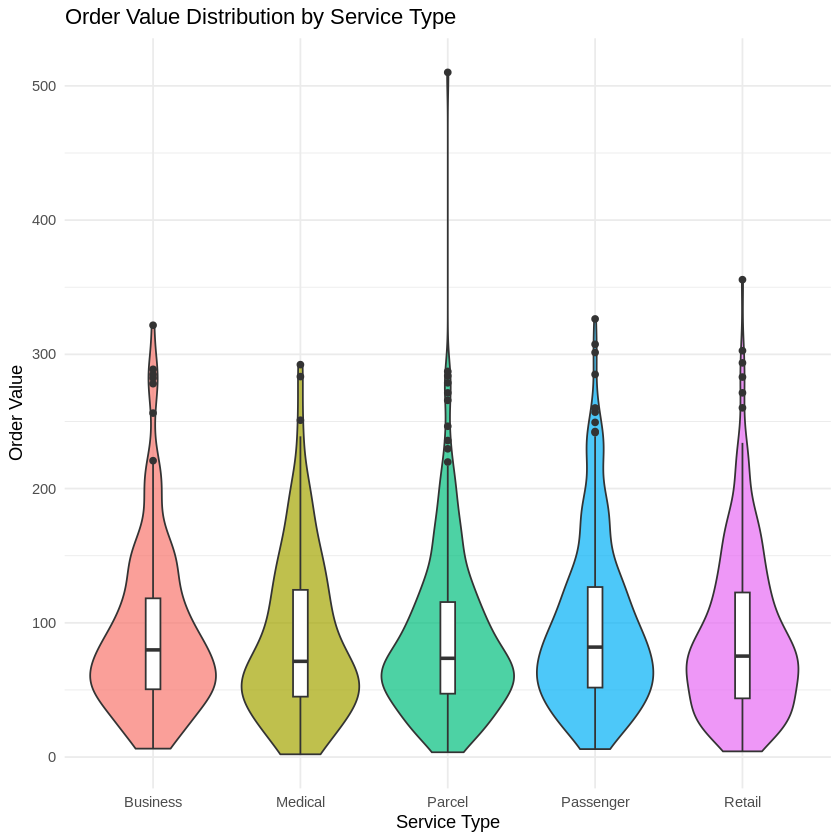

In [17]:
# CHART 5 — ORDER VALUE BY SERVICE TYPE
order_analysis <- orders

ggplot(order_analysis,
       aes(x = service_type,
           y = order_value,
           fill = service_type)) +

  geom_violin(alpha = 0.7) +

  geom_boxplot(
    width = 0.1,
    fill = "white"
  ) +

  labs(
    title = "Order Value Distribution by Service Type",
    x = "Service Type",
    y = "Order Value"
  ) +

  theme_minimal() +

  theme(
    legend.position = "none"
  )

In [18]:
# STEP 8 — SUMMARY STATISTICS

summary_stats <- deliveries %>%
  summarise(
    avg_distance = mean(route_distance_km, na.rm = TRUE),
    avg_rating = mean(customer_rating_post_delivery, na.rm = TRUE),
    avg_cost = mean(fuel_or_charge_cost, na.rm = TRUE),
    total_overrides = sum(manual_route_override_count, na.rm = TRUE)
  )

summary_stats

avg_distance,avg_rating,avg_cost,total_overrides
<dbl>,<dbl>,<dbl>,<int>
13.90932,3.864679,12.84129,921


In [19]:
# STEP 9 — CORRELATION ANALYSIS

correlation_data <- deliveries %>%
  select(
    route_distance_km,
    manual_route_override_count,
    customer_rating_post_delivery,
    fuel_or_charge_cost
  ) %>%
  na.omit()

cor_matrix <- cor(correlation_data)

round(cor_matrix, 2)

,route_distance_km,manual_route_override_count,customer_rating_post_delivery,fuel_or_charge_cost
route_distance_km,1.00,0.20,0.03,0.53
manual_route_override_count,0.20,1.00,-0.06,0.10
customer_rating_post_delivery,0.03,-0.06,1.00,-0.06
fuel_or_charge_cost,0.53,0.10,-0.06,1.00


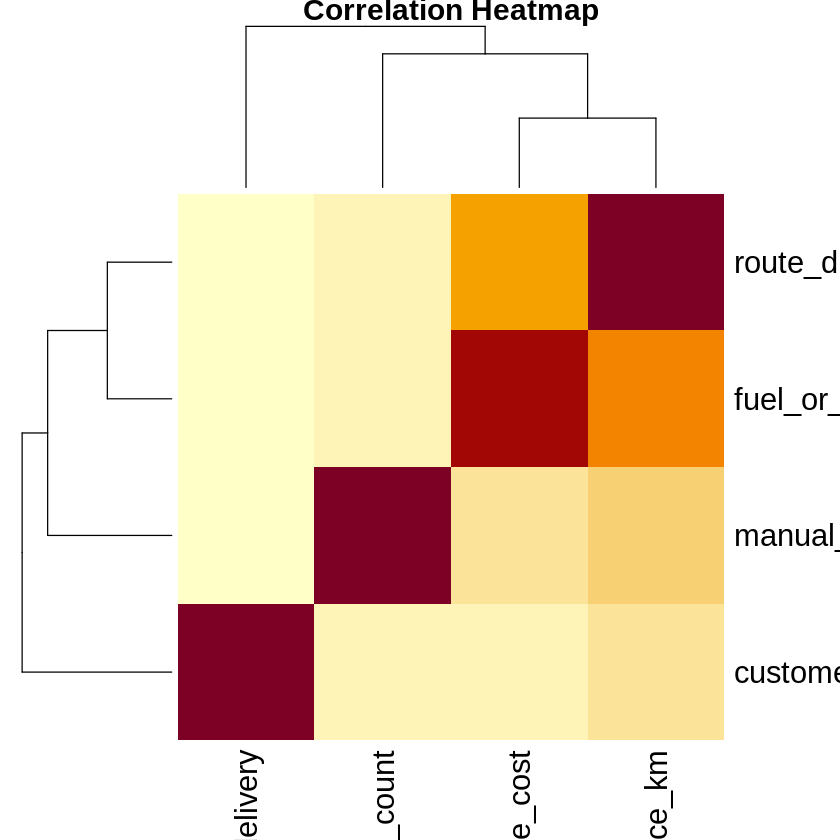

In [20]:
# STEP 10 — CORRELATION HEATMAP

heatmap(
  cor_matrix,
  main = "Correlation Heatmap"
)